# 🍷 Wine Tasting → Particle Effect
### Random Forest 학습 + Feature Space 시각화

**흐름:**
```
CSV 로드 → 전처리 → Train/Test 분리 → RF 학습 → 평가 → 시각화
```

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 1. 데이터 로드 & 탐색

In [10]:
df = pd.read_csv('wine_tasting_dataset.csv')

print(f'총 샘플 수: {len(df)}')
print(f'컬럼 수   : {len(df.columns)}')
print(f'\n와인 타입 분포:')
print(df['wine_type'].value_counts())
print(f'\n스타일 분포:')
print(df['style'].value_counts())
print(f'\nparticle_type 분포:')
print(df['particle_type'].value_counts().sort_index())
df.head()

총 샘플 수: 400
컬럼 수   : 36

와인 타입 분포:
wine_type
red      200
white    200
Name: count, dtype: int64

스타일 분포:
style
bold_red     62
crisp        61
rich         57
light_red    46
earthy       39
aromatic     36
aged         27
fruity       26
oxidative    24
sweet        22
Name: count, dtype: int64

particle_type 분포:
particle_type
0    158
1     96
2     63
3     43
4     40
Name: count, dtype: int64


,wine_type,style,color_depth,color_straw,color_lemon,color_gold,color_amber,color_brown,color_purple,color_ruby,...,score_complexity,score_intensity,particle_type,particle_size,particle_count,particle_speed,gravity,color_r,color_g,color_b
0,red,light_red,0.212791,0,0,0,0,0,0,0,...,0.279941,0.427861,1,2.254,283,0.630,-0.501,0.281,0.000,0.328
1,red,bold_red,0.990565,0,0,0,0,0,1,0,...,0.774087,0.663541,2,4.784,43,0.363,0.676,0.603,0.019,0.133
2,white,rich,0.523397,0,0,1,0,0,0,0,...,0.731921,0.676922,4,3.423,17,0.343,0.050,0.715,0.690,0.232
3,red,light_red,0.110870,0,0,0,0,0,0,0,...,0.271249,0.207274,1,2.431,65,0.682,-0.314,0.307,0.068,0.285
4,white,rich,0.431198,0,0,0,0,0,0,0,...,0.930156,0.660190,0,4.455,222,0.549,-0.060,0.711,0.756,0.597


In [11]:
# 기초 통계
label_cols = ['particle_type','particle_size','particle_count','particle_speed','gravity','color_r','color_g','color_b']
df[label_cols].describe().round(3)

,particle_type,particle_size,particle_count,particle_speed,gravity,color_r,color_g,color_b
count,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000
mean,1.278,3.482,164.800,0.500,-0.043,0.601,0.355,0.273
std,1.345,1.014,93.685,0.144,0.405,0.163,0.311,0.178
min,0.000,1.000,10.000,0.095,-0.931,0.256,0.000,0.000
25%,0.000,2.636,93.000,0.406,-0.366,0.465,0.046,0.116
50%,1.000,3.574,166.000,0.507,-0.034,0.616,0.300,0.259
75%,2.000,4.339,248.000,0.595,0.311,0.725,0.661,0.410
max,4.000,5.000,300.000,0.884,0.908,0.974,0.873,0.745


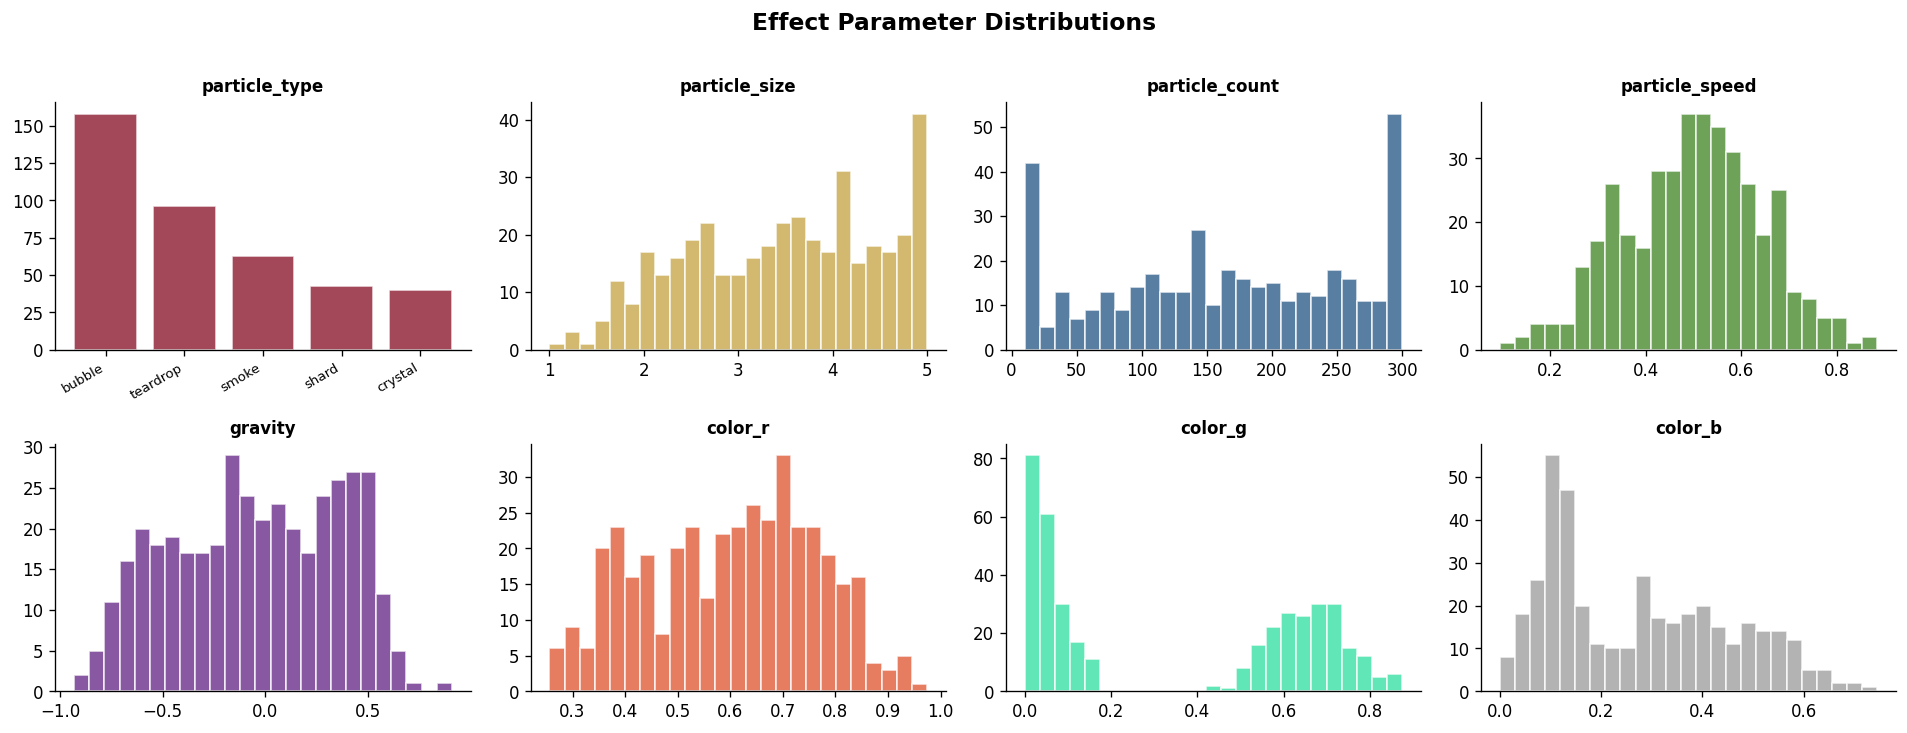

In [12]:
# Effect 파라미터 분포 시각화
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Effect Parameter Distributions', fontsize=14, fontweight='bold', y=1.01)

colors = ['#8B1A2E','#C9A84C','#2E5E8B','#4A8B2E','#6B2E8B','#E05C3A','#3AE0A5','#A0A0A0']

for ax, col, c in zip(axes.flat, label_cols, colors):
    if col == 'particle_type':
        type_names = ['bubble','teardrop','smoke','shard','crystal']
        counts = df[col].value_counts().sort_index()
        ax.bar(type_names[:len(counts)], counts.values, color=c, alpha=0.8, edgecolor='white')
        ax.set_xticklabels(type_names[:len(counts)], rotation=30, ha='right', fontsize=8)
    else:
        ax.hist(df[col], bins=25, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('01_effect_distributions.png', bbox_inches='tight')
plt.show()

## 2. 전처리 & Feature / Label 분리

In [13]:
# wine_type one-hot
df['is_red'] = (df['wine_type'] == 'red').astype(int)

FEATURE_COLS = [
    'is_red',
    # 외관
    'color_depth',
    'color_straw','color_lemon','color_gold','color_amber','color_brown',
    'color_purple','color_ruby','color_garnet',
    # 후각
    'nose_intensity',
    'fruit_green','fruit_citrus','fruit_stone','fruit_tropical',
    'fruit_red','fruit_black',
    'secondary_oak','secondary_creamy','tertiary_present',
    'development',
    # 미각
    'acidity','body','finish','tannin',
    # 결론
    'score_complexity','score_intensity'
]

LABEL_COLS = ['particle_type','particle_size','particle_count',
              'particle_speed','gravity','color_r','color_g','color_b']

X = df[FEATURE_COLS].values.astype(float)
y = df[LABEL_COLS].values.astype(float)

# particle_count 정규화 (스케일이 너무 큼)
scaler_count = MinMaxScaler()
y_norm = y.copy()
y_norm[:, 2] = scaler_count.fit_transform(y[:, 2].reshape(-1,1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y_norm, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Feature dims: {len(FEATURE_COLS)}')
print(f'Label dims  : {len(LABEL_COLS)}')

Train: (320, 27), Test: (80, 27)
Feature dims: 27
Label dims  : 8


## 3. Random Forest 학습

In [14]:
# MultiOutputRegressor: 8개 label을 동시에 예측
rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
)

rf.fit(X_train, y_train)
print('✅ 학습 완료')

# particle_type은 분류 문제처럼 다루기
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train[:, 0].round().astype(int))
print('✅ 분류 모델(particle_type) 학습 완료')

✅ 학습 완료
✅ 분류 모델(particle_type) 학습 완료


In [15]:
## 모델 저장 (Flask 앱에서 사용)
import joblib, os
os.makedirs('models', exist_ok=True)
joblib.dump(rf,           'models/rf_regressor.pkl')
joblib.dump(rf_clf,       'models/rf_classifier.pkl')
joblib.dump(scaler_count, 'models/scaler_count.pkl')
print('✅ 모델 저장 완료 → models/ 폴더')
print('   rf_regressor.pkl  / rf_classifier.pkl / scaler_count.pkl')

✅ 모델 저장 완료 → models/ 폴더
   rf_regressor.pkl  / rf_classifier.pkl / scaler_count.pkl


## 4. 모델 평가

In [ ]:
y_pred = rf.predict(X_test)

print('=' * 55)
print(f'{"Parameter":<22}  {"MAE":>7}  {"R^2":>7}')
print('=' * 55)
for i, col in enumerate(LABEL_COLS):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2  = r2_score(y_test[:, i], y_pred[:, i])
    flag = '🟢' if r2 > 0.75 else ('🟡' if r2 > 0.5 else '🔴')
    print(f'  {col:<22}  {mae:>7.4f}  {r2:>7.3f}  {flag}')
print('=' * 55)

# particle_type accuracy
pt_pred = rf_clf.predict(X_test)
pt_true = y_test[:, 0].round().astype(int)
acc = accuracy_score(pt_true, pt_pred)
print(f'\nparticle_type Accuracy: {acc:.3f}')

SyntaxError: f-string: expecting '}' (2291110399.py, line 4)

In [ ]:
# Prediction vs Actual 시각화 (연속형 파라미터)
cont_labels = ['particle_size','particle_count','particle_speed','gravity','color_r','color_g','color_b']
cont_idx    = [1, 2, 3, 4, 5, 6, 7]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Predicted vs Actual', fontsize=14, fontweight='bold')
colors = ['#C9A84C','#2E5E8B','#4A8B2E','#6B2E8B','#E05C3A','#3AE0A5','#A0A0A0']

for ax, col, idx, c in zip(axes.flat, cont_labels, cont_idx, colors):
    ax.scatter(y_test[:, idx], y_pred[:, idx], alpha=0.4, s=15, color=c)
    mn = min(y_test[:, idx].min(), y_pred[:, idx].min())
    mx = max(y_test[:, idx].max(), y_pred[:, idx].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, alpha=0.7, label='perfect')
    r2 = r2_score(y_test[:, idx], y_pred[:, idx])
    ax.set_title(f'{col}\nR²={r2:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# particle_type confusion matrix
ax = axes.flat[-1]
cm = confusion_matrix(pt_true, pt_pred, labels=[0,1,2,3,4])
type_names = ['bubble','tear','smoke','shard','crystal']
sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=type_names, yticklabels=type_names,
            cbar=False, linewidths=0.5)
ax.set_title(f'particle_type\nAccuracy={acc:.3f}', fontsize=9, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=8)
ax.set_ylabel('Actual', fontsize=8)

plt.tight_layout()
plt.savefig('02_pred_vs_actual.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance

In [ ]:
# 각 output별 feature importance 추출
importances = np.array([est.feature_importances_ for est in rf.estimators_])
mean_imp = importances.mean(axis=0)
fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': mean_imp})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors_fi = ['#8B1A2E' if i > len(fi_df)-6 else '#C9A84C' for i in range(len(fi_df))]
bars = ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi, edgecolor='white', height=0.7)
ax.set_title('Feature Importance (Mean across all outputs)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=mean_imp.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Mean={mean_imp.mean():.3f}')
ax.legend(fontsize=9)

# 값 라벨
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('03_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# Output별 top feature importance 히트맵
imp_matrix = np.array([est.feature_importances_ for est in rf.estimators_])

fig, ax = plt.subplots(figsize=(14, 5))
top_n = 15
top_feat_idx = np.argsort(mean_imp)[::-1][:top_n]
top_feat_names = [FEATURE_COLS[i] for i in top_feat_idx]
imp_sub = imp_matrix[:, top_feat_idx]  # (8 outputs, top_n features)

sns.heatmap(imp_sub, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
            xticklabels=top_feat_names,
            yticklabels=LABEL_COLS,
            linewidths=0.5, cbar_kws={'label': 'Importance'})
ax.set_title('Feature Importance per Output Parameter (Top 15 features)', fontsize=12, fontweight='bold', pad=12)
ax.set_xticklabels(top_feat_names, rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('04_importance_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Feature Space 시각화 — PCA & 결정 경계

In [ ]:
# PCA로 27dim → 2dim 축소
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

labels_for_plot = df['style'].values
wine_types      = df['wine_type'].values
ptypes          = df['particle_type'].values

var_exp = pca.explained_variance_ratio_
print(f'PC1 설명 분산: {var_exp[0]:.3f} ({var_exp[0]*100:.1f}%)')
print(f'PC2 설명 분산: {var_exp[1]:.3f} ({var_exp[1]*100:.1f}%)')
print(f'합계         : {sum(var_exp):.3f} ({sum(var_exp)*100:.1f}%)')

In [ ]:
# ── 6-1. PCA 공간 - 와인 스타일 분포 ──────────────────────
style_colors = {
    'crisp':     '#7EC8E3', 'rich':      '#C9A84C',
    'sweet':     '#F4A261', 'aromatic':  '#A8DADC',
    'oxidative': '#8B5E3C', 'light_red': '#FF9999',
    'bold_red':  '#8B1A2E', 'earthy':    '#6B4226',
    'fruity':    '#E63946', 'aged':      '#4A1942'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Feature Space (27dim → 2dim)', fontsize=14, fontweight='bold')

# 스타일별 색상
ax = axes[0]
for style, color in style_colors.items():
    mask = labels_for_plot == style
    if mask.sum() > 0:
        marker = 'o' if df[mask]['wine_type'].iloc[0] == 'white' else 's'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=style, alpha=0.7, s=45,
                   marker=marker, edgecolors='white', linewidths=0.4)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)', fontsize=10)
ax.set_title('Wine Style Clusters\n(○=White, □=Red)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)

# particle_type별 색상
ax = axes[1]
ptype_colors = ['#4FC3F7','#81C784','#FFB74D','#E57373','#CE93D8']
ptype_names  = ['bubble','teardrop','smoke','shard','crystal']
for i, (c, name) in enumerate(zip(ptype_colors, ptype_names)):
    mask = ptypes == i
    if mask.sum() > 0:
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=c, label=f'{i}: {name}', alpha=0.7, s=45,
                   edgecolors='white', linewidths=0.4)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)', fontsize=10)
ax.set_title('Particle Type Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('05_pca_feature_space.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 6-2. PCA 공간에서 Gravity & Speed 분포 (컬러맵) ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect Parameters in PCA Feature Space', fontsize=13, fontweight='bold')

params = [
    ('gravity',        'RdBu_r',    'Gravity (↑위 / ↓아래)'),
    ('particle_speed', 'plasma',    'Particle Speed'),
    ('particle_size',  'YlOrRd',    'Particle Size'),
]

for ax, (param, cmap, title) in zip(axes, params):
    vals = df[param].values
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=vals, cmap=cmap, alpha=0.7, s=40,
                    edgecolors='white', linewidths=0.3)
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(param, fontsize=8)
    ax.set_xlabel(f'PC1', fontsize=9)
    ax.set_ylabel(f'PC2', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.3)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('06_pca_effect_params.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 6-3. 결정 경계 (Decision Boundary) - particle_type ────
# PCA 2D 공간에서 RF classifier의 결정 경계 시각화

rf_clf_2d = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_clf_2d.fit(X_2d, ptypes)

h = 0.05
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = rf_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))

# 배경 결정 경계
bg_colors = ['#B3E5FC','#C8E6C9','#FFE0B2','#FFCDD2','#E1BEE7']
from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(bg_colors)
ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=[-0.5,0.5,1.5,2.5,3.5,4.5])
ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.6, levels=[-0.5,0.5,1.5,2.5,3.5,4.5])

# 데이터 포인트
for i, (c, name) in enumerate(zip(ptype_colors, ptype_names)):
    mask = ptypes == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=c, label=f'{name}', s=50, alpha=0.85,
               edgecolors='#333', linewidths=0.5)

# White/Red 구분 마커 추가
for wt, marker, label in [('white','o','White'), ('red','s','Red')]:
    mask = wine_types == wt
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c='none', s=70, marker=marker,
               edgecolors='black', linewidths=0.8, alpha=0.3, zorder=5)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% explained variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% explained variance)', fontsize=11)
ax.set_title('Decision Boundary — Particle Type\n(PCA 2D Feature Space)', fontsize=13, fontweight='bold')
ax.legend(title='Particle Type', fontsize=9, title_fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 범례에 White/Red 마커 추가
from matplotlib.lines import Line2D
extra = [Line2D([0],[0], marker='o', color='w', markeredgecolor='black', markersize=8, label='White wine'),
         Line2D([0],[0], marker='s', color='w', markeredgecolor='black', markersize=8, label='Red wine')]
ax.legend(handles=ax.get_legend_handles_labels()[0] + extra,
          labels=ax.get_legend_handles_labels()[1] + ['White wine','Red wine'],
          fontsize=9, title='Particle Type / Wine Type', title_fontsize=9)

plt.tight_layout()
plt.savefig('07_decision_boundary.png', bbox_inches='tight')
plt.show()
print(f'2D RF Accuracy: {rf_clf_2d.score(X_2d, ptypes):.3f}')

In [ ]:
# ── 6-4. 핵심 Feature 쌍별 Scatter + Effect 오버레이 ───────
key_pairs = [
    ('acidity', 'body',      'gravity'),
    ('nose_intensity', 'score_complexity', 'particle_count'),
    ('development', 'tannin',  'particle_speed'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Feature Pairs vs Effect Parameter', fontsize=13, fontweight='bold')

for ax, (fx, fy, fz) in zip(axes, key_pairs):
    sc = ax.scatter(df[fx], df[fy], c=df[fz], cmap='RdYlGn' if fz=='gravity' else 'plasma',
                    s=40, alpha=0.75, edgecolors='white', linewidths=0.3)
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(fz, fontsize=8)
    ax.set_xlabel(fx, fontsize=10)
    ax.set_ylabel(fy, fontsize=10)
    ax.set_title(f'{fx} vs {fy}\n→ color: {fz}', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('08_feature_pairs.png', bbox_inches='tight')
plt.show()

## 7. 새 테이스팅 시트 → Effect 예측 (추론)

In [ ]:
def predict_effect(raw: dict, rf_reg, rf_cls, scaler_cnt, feature_cols) -> dict:
    """테이스팅 시트 딕셔너리 → Effect 파라미터 딕셔너리"""
    vec = [raw.get(f, 0.0) for f in feature_cols]
    X_in = np.array(vec).reshape(1, -1)

    pred = rf_reg.predict(X_in)[0]
    ptype = int(rf_cls.predict(X_in)[0])

    # particle_count 역변환
    pcount_norm = np.clip(pred[2], 0, 1)
    pcount = int(scaler_cnt.inverse_transform([[pcount_norm]])[0][0])

    ptype_names = ['bubble','teardrop','smoke','shard','crystal']
    return {
        'particle_type':  ptype,
        'particle_type_name': ptype_names[ptype],
        'particle_size':  round(float(np.clip(pred[1], 1.0, 5.0)), 3),
        'particle_count': int(np.clip(pcount, 10, 300)),
        'particle_speed': round(float(np.clip(pred[3], 0.0, 1.0)), 3),
        'gravity':        round(float(np.clip(pred[4], -1.0, 1.0)), 3),
        'color_r':        round(float(np.clip(pred[5], 0.0, 1.0)), 3),
        'color_g':        round(float(np.clip(pred[6], 0.0, 1.0)), 3),
        'color_b':        round(float(np.clip(pred[7], 0.0, 1.0)), 3),
    }

# ─── 테스트 케이스 1: Bold Napa Cabernet ───────────────────
cabernet = {
    'is_red': 1,
    'color_depth': 0.9, 'color_ruby': 1, 'color_purple': 1,
    'nose_intensity': 0.9,
    'fruit_red': 1, 'fruit_black': 1,
    'secondary_oak': 1, 'secondary_creamy': 0,
    'tertiary_present': 1, 'development': 0.4,
    'acidity': 0.5, 'body': 1.0, 'finish': 0.9, 'tannin': 0.9,
    'score_complexity': 0.9, 'score_intensity': 0.95,
}

# ─── 테스트 케이스 2: Crisp Chablis ────────────────────────
chablis = {
    'is_red': 0,
    'color_depth': 0.2, 'color_straw': 1, 'color_lemon': 1,
    'nose_intensity': 0.45,
    'fruit_green': 1, 'fruit_citrus': 1,
    'secondary_oak': 0, 'secondary_creamy': 0,
    'tertiary_present': 0, 'development': 0.1,
    'acidity': 0.9, 'body': 0.2, 'finish': 0.45, 'tannin': 0.0,
    'score_complexity': 0.4, 'score_intensity': 0.5,
}

# ─── 테스트 케이스 3: Sweet Sauternes ──────────────────────
sauternes = {
    'is_red': 0,
    'color_depth': 0.6, 'color_gold': 1, 'color_amber': 1,
    'nose_intensity': 0.8,
    'fruit_stone': 1, 'fruit_tropical': 1,
    'secondary_oak': 0, 'secondary_creamy': 1,
    'tertiary_present': 1, 'development': 0.6,
    'acidity': 0.55, 'body': 0.7, 'finish': 0.9, 'tannin': 0.0,
    'score_complexity': 0.85, 'score_intensity': 0.8,
}

test_cases = [
    ('Bold Napa Cabernet 🍷', cabernet),
    ('Crisp Chablis 🥂',      chablis),
    ('Sweet Sauternes 🍯',    sauternes),
]

results = {}
for name, raw in test_cases:
    eff = predict_effect(raw, rf, rf_clf, scaler_count, FEATURE_COLS)
    results[name] = eff
    print(f'\n── {name} ────────────────────────')
    for k, v in eff.items():
        print(f'  {k:<22}: {v}')

In [ ]:
# ── Effect 결과 비교 시각화 ───────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0A0A0A')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

wine_names  = list(results.keys())
wine_colors = [
    (results[w]['color_r'], results[w]['color_g'], results[w]['color_b'])
    for w in wine_names
]

# 레이더 차트용 파라미터
radar_params = ['particle_size','particle_speed','gravity_norm','color_intensity','complexity_proxy']

# 레이더 데이터 계산
def make_radar_data(eff):
    return [
        (eff['particle_size'] - 1) / 4,               # 0~1
        eff['particle_speed'],
        (eff['gravity'] + 1) / 2,                     # -1~1 → 0~1
        (eff['color_r'] + eff['color_g'] + eff['color_b']) / 3,
        eff['particle_count'] / 300,
    ]

# ── 서브플롯 1: 파라미터 비교 바 차트 ────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#111111')

compare_params = ['particle_size','particle_speed','color_r','color_g','color_b']
x = np.arange(len(compare_params))
width = 0.25

for i, (name, wc) in enumerate(zip(wine_names, wine_colors)):
    vals = [results[name][p] for p in compare_params]
    # particle_size 정규화
    vals[0] = (vals[0] - 1) / 4
    bars = ax1.bar(x + i*width - width, vals, width, label=name,
                   color=wc, alpha=0.85, edgecolor='white', linewidth=0.5)

ax1.set_xticks(x)
ax1.set_xticklabels(compare_params, fontsize=10, color='white')
ax1.set_title('Effect Parameters Comparison (normalized)', fontsize=12, fontweight='bold', color='white', pad=10)
ax1.legend(fontsize=9, labelcolor='white', facecolor='#222222', edgecolor='#444444')
ax1.set_facecolor('#111111')
ax1.tick_params(colors='white')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444444')
ax1.set_ylim(0, 1.1)
ax1.yaxis.label.set_color('white')
ax1.set_ylabel('Normalized Value', color='white', fontsize=9)

# ── 서브플롯 2~4: 각 와인 파티클 미리보기 ─────────────────
ptype_names = ['bubble','teardrop','smoke','shard','crystal']

for col_idx, (name, wc) in enumerate(zip(wine_names, wine_colors)):
    ax = fig.add_subplot(gs[1, col_idx])
    ax.set_facecolor('#0D0D0D')
    eff = results[name]

    n_pts = min(eff['particle_count'], 120)
    speed = eff['particle_speed']
    grav  = eff['gravity']
    size  = eff['particle_size'] * 8
    ptype = eff['particle_type']
    color = wc

    np.random.seed(col_idx)
    # gravity에 따른 y 분포
    if grav < -0.2:   # 위로
        y_pts = np.random.beta(1.5, 4, n_pts)
    elif grav > 0.2:  # 아래로
        y_pts = np.random.beta(4, 1.5, n_pts)
    else:             # 정지
        y_pts = np.random.uniform(0.2, 0.8, n_pts)

    x_pts = np.random.uniform(0.05, 0.95, n_pts)

    # speed에 따른 alpha 변화 (trail 효과)
    alphas = np.random.uniform(0.3, 0.9, n_pts) * (0.5 + speed * 0.5)
    sizes  = np.random.uniform(size*0.5, size*1.5, n_pts)

    # ptype별 마커
    markers = ['o', 'v', '*', 'D', 'p']
    mkr = markers[ptype % len(markers)]

    ax.scatter(x_pts, y_pts, c=[color]*n_pts, s=sizes,
               alpha=alphas, marker=mkr,
               edgecolors='white', linewidths=0.2)

    # gravity 화살표
    arrow_dir = -grav * 0.12
    ax.annotate('', xy=(0.92, 0.5 + arrow_dir), xytext=(0.92, 0.5),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    short_name = name.split(' ')[0] + ' ' + name.split(' ')[1]
    ax.set_title(f'{short_name}\ntype={ptype_names[ptype]} | n={eff["particle_count"]} | g={eff["gravity"]:+.2f}',
                 fontsize=8.5, color='white', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

fig.text(0.5, 0.01, 'Wine Tasting → Particle Effect Preview', ha='center',
         fontsize=10, color='#888888')

plt.savefig('09_effect_preview.png', bbox_inches='tight', facecolor='#0A0A0A')
plt.show()

## 8. 상관관계 분석 — Feature ↔ Effect

In [ ]:
# 핵심 feature와 effect label 간 상관관계
key_features = ['acidity','body','tannin','development','nose_intensity',
                'secondary_oak','tertiary_present','score_complexity','score_intensity']
corr_df = df[key_features + LABEL_COLS].corr()
cross_corr = corr_df.loc[LABEL_COLS, key_features]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross_corr, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Pearson r'},
            vmin=-0.8, vmax=0.8)
ax.set_title('Feature ↔ Effect Parameter Correlation', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(key_features, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(LABEL_COLS, rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('10_correlation.png', bbox_inches='tight')
plt.show()

## 9. 요약

In [ ]:
print('=' * 60)
print('  SUMMARY')
print('=' * 60)
print(f'  학습 데이터  : {len(X_train)}개')
print(f'  테스트 데이터: {len(X_test)}개')
print(f'  Feature 차원 : {len(FEATURE_COLS)}dim')
print(f'  Output 파라미터: {len(LABEL_COLS)}개')
print()

y_pred_final = rf.predict(X_test)
r2_scores = [r2_score(y_test[:,i], y_pred_final[:,i]) for i in range(len(LABEL_COLS))]
print('  R² per parameter:')
for col, r2 in zip(LABEL_COLS, r2_scores):
    bar = '█' * int(r2 * 20) + '░' * (20 - int(r2 * 20))
    print(f'    {col:<22} [{bar}] {r2:.3f}')
print()
print(f'  particle_type Accuracy: {acc:.3f}')
print(f'  Mean R²: {np.mean(r2_scores):.3f}')
print('=' * 60)
print()
print('  다음 단계 추천:')
print('  1. 실제 레이블 데이터 수집 (슬라이더 UI로 수동 조정)')
print('  2. R² 낮은 파라미터는 feature 추가 검토')
print('  3. 데이터 500+ 확보 시 MLP/VAE로 업그레이드')
print('  4. 추론 API 구축 → Unity particle system 연결')